In [15]:
# @title
import zipfile
import os
from pathlib import Path

# Dosyayı bulmak için otomatik arama yapalım
print("🔍 Dosya aranıyor...")
search_results = !find /content/drive/MyDrive -name "MultiRes_ConfocFluo_HumanDentin.zip"

if search_results:
    ZIP_PATH = search_results[0]
    print(f"✅ Dosya bulundu: {ZIP_PATH}")
else:
    # Eğer bulunamazsa varsayılanı bırakalım veya kullanıcıdan manuel girmesini isteyelim
    ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"
    print("❌ Dosya bulunamadı! Lütfen ZIP_PATH değişkenini manuel güncelleyin.")

EXTRACT_PATH = "/content/dataset"

if os.path.exists(ZIP_PATH):
    print("📦 Sadece ImagePatches128 açılıyor...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        patches_dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
        toplam = len(patches_dosyalar)
        print(f"Açılacak dosya sayısı: {toplam:,}")

        for i, dosya in enumerate(patches_dosyalar):
            z.extract(dosya, EXTRACT_PATH)
            if i % 10000 == 0:
                print(f"  {i:,} / {toplam:,} ({i/toplam*100:.0f}%)")
    print("\n✅ ImagePatches128 açıldı!")
else:
    print("\n⚠️ İşlem durduruldu: Geçerli bir dosya yolu yok.")

🔍 Dosya aranıyor...
✅ Dosya bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
📦 Sadece ImagePatches128 açılıyor...
Açılacak dosya sayısı: 361,873
  0 / 361,873 (0%)
  10,000 / 361,873 (3%)
  20,000 / 361,873 (6%)
  30,000 / 361,873 (8%)
  40,000 / 361,873 (11%)
  50,000 / 361,873 (14%)
  60,000 / 361,873 (17%)
  70,000 / 361,873 (19%)
  80,000 / 361,873 (22%)
  90,000 / 361,873 (25%)
  100,000 / 361,873 (28%)
  110,000 / 361,873 (30%)
  120,000 / 361,873 (33%)
  130,000 / 361,873 (36%)
  140,000 / 361,873 (39%)
  150,000 / 361,873 (41%)
  160,000 / 361,873 (44%)
  170,000 / 361,873 (47%)
  180,000 / 361,873 (50%)
  190,000 / 361,873 (53%)
  200,000 / 361,873 (55%)
  210,000 / 361,873 (58%)
  220,000 / 361,873 (61%)
  230,000 / 361,873 (64%)
  240,000 / 361,873 (66%)
  250,000 / 361,873 (69%)
  260,000 / 361,873 (72%)
  270,000 / 361,873 (75%)
  280,000 / 361,873 (77%)
  290,000 / 361,873 (80%)
  300,000 / 361,873 (83%)
  310,000 / 361,873 (86%)
  320,000 / 361,873 (88

In [16]:
# ============================================================
# HÜCRE 1: DRIVE BAĞLA + ZIP AÇ
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile, os
from pathlib import Path

ZIP_PATH = None
EXTRACT_PATH = "/content/dataset"

# Drive'daki zip'i otomatik bul
print("🔍 Zip dosyası aranıyor...")
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if "MultiRes" in f and f.endswith(".zip"):
            ZIP_PATH = os.path.join(root, f)
            break
    if ZIP_PATH:
        break

if ZIP_PATH is None:
    # Alt klasörlerde de ara
    import subprocess
    r = subprocess.run(['find', '/content/drive/MyDrive', '-name',
                       '*MultiRes*.zip', '-maxdepth', '5'],
                      capture_output=True, text=True, timeout=30)
    if r.stdout.strip():
        ZIP_PATH = r.stdout.strip().split('\n')[0]

print(f"✅ Zip bulundu: {ZIP_PATH}")
print(f"   Boyut: {os.path.getsize(ZIP_PATH) / (1024**3):.2f} GB")

# ImagePatches128 zaten açık mı?
check = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin" / "ImagePatches128" / "Classified"
if check.exists():
    print("✅ Dataset zaten açık!")
else:
    print("📦 Sadece ImagePatches128 açılıyor (~5 dk)...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
        toplam = len(dosyalar)
        for i, d in enumerate(dosyalar):
            z.extract(d, EXTRACT_PATH)
            if i % 50000 == 0:
                print(f"  {i:,}/{toplam:,} ({i/toplam*100:.0f}%)")
    print("✅ Açıldı!")

# Kontrol
p = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified"
for sinif in ["tubules","branches","both"]:
    sayi = len(list((p/sinif/"HR").glob("*.tif")))
    print(f"  {sinif}/HR: {sayi:,}")

Mounted at /content/drive
🔍 Zip dosyası aranıyor...
✅ Zip bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
   Boyut: 2.70 GB
✅ Dataset zaten açık!
  tubules/HR: 5,201
  branches/HR: 32,010
  both/HR: 53,253


In [17]:
# ============================================================
# HÜCRE 2: SABİTLER + DATASET + DATALOADER
# ============================================================
import torch, warnings
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
from collections import Counter
import tifffile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 64
NUM_EPOCHS    = 20
LR            = 1e-3
RANDOM_SEED   = 42
torch.manual_seed(RANDOM_SEED)

PATCHES_ROOT  = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR      = ["tubules", "branches", "both"]
SINIF2IDX     = {s: i for i, s in enumerate(SINIFLAR)}
IDX2SINIF     = {i: s for s, i in SINIF2IDX.items()}
CLASS_WEIGHTS = torch.tensor([2.3807, 0.3868, 0.2325]).to(DEVICE)
TRAIN_ROIS    = ["roi01","roi02","roi03","roi04"]
VAL_ROIS      = ["roi05"]
TEST_ROIS     = ["roi06"]

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            if get_roi(tif.name) in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

class DentinDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]
    def __init__(self, dosya_listesi, augmentation=False):
        self.dosya_listesi = dosya_listesi
        self.augmentation  = augmentation
        self.train_tf = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
        self.val_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        tf  = self.train_tf if self.augmentation else self.val_tf
        return tf(img), torch.tensor(etiket, dtype=torch.long)

train_d = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TRAIN_ROIS), True)
val_d   = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", VAL_ROIS),   False)
test_d  = DentinDataset(build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TEST_ROIS),  False)

train_loader = DataLoader(train_d, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_d,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_d,  BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Device : {DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"✅ Train  : {len(train_d):,} patch → {len(train_loader)} batch")
print(f"✅ Val    : {len(val_d):,} patch → {len(val_loader)} batch")
print(f"✅ Test   : {len(test_d):,} patch → {len(test_loader)} batch")

✅ Device : cuda (Tesla T4)
✅ Train  : 60,125 patch → 940 batch
✅ Val    : 13,393 patch → 210 batch
✅ Test   : 16,946 patch → 265 batch


In [18]:
# ============================================================
# HÜCRE 3: BASELINE CNN MİMARİSİ
# ============================================================
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = BaselineCNN().to(DEVICE)
toplam = sum(p.numel() for p in model.parameters())
print(f"✅ Baseline CNN: {toplam:,} parametre")

test_in = torch.randn(4, 3, 128, 128).to(DEVICE)
test_out = model(test_in)
print(f"   Giriş: {test_in.shape} → Çıkış: {test_out.shape} ✓")

✅ Baseline CNN: 8,483,331 parametre
   Giriş: torch.Size([4, 3, 128, 128]) → Çıkış: torch.Size([4, 3]) ✓


In [19]:
# ============================================================
# HÜCRE 4: EĞİTİM
# ============================================================
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

tarih = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
en_iyi_val_acc = 0.0
en_iyi_epoch   = 0

print("="*60)
print(f"EĞİTİM BAŞLIYOR — {NUM_EPOCHS} epoch, Baseline CNN, HR")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t_loss, t_dogru, t_toplam = 0, 0, 0
    for imgs, eti in train_loader:
        imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
        optimizer.zero_grad()
        cikti = model(imgs)
        loss  = criterion(cikti, eti)
        loss.backward()
        optimizer.step()
        t_loss   += loss.item() * imgs.size(0)
        t_dogru  += (cikti.argmax(1) == eti).sum().item()
        t_toplam += imgs.size(0)

    model.eval()
    v_loss, v_dogru, v_toplam = 0, 0, 0
    with torch.no_grad():
        for imgs, eti in val_loader:
            imgs, eti = imgs.to(DEVICE), eti.to(DEVICE)
            cikti = model(imgs)
            loss  = criterion(cikti, eti)
            v_loss   += loss.item() * imgs.size(0)
            v_dogru  += (cikti.argmax(1) == eti).sum().item()
            v_toplam += imgs.size(0)

    tl = t_loss/t_toplam; vl = v_loss/v_toplam
    ta = t_dogru/t_toplam*100; va = v_dogru/v_toplam*100
    tarih["train_loss"].append(tl); tarih["val_loss"].append(vl)
    tarih["train_acc"].append(ta);  tarih["val_acc"].append(va)

    kayit = ""
    if va > en_iyi_val_acc:
        en_iyi_val_acc = va; en_iyi_epoch = epoch
        torch.save(model.state_dict(), "baseline_best.pth")
        kayit = " ★"

    scheduler.step()
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train: {tl:.4f} %{ta:.1f} | Val: {vl:.4f} %{va:.1f}{kayit}")

print(f"\n✅ Bitti! En iyi: %{en_iyi_val_acc:.2f} (epoch {en_iyi_epoch})")

EĞİTİM BAŞLIYOR — 20 epoch, Baseline CNN, HR
Epoch  1/20 | Train: 0.9352 %54.4 | Val: 0.8803 %61.6 ★
Epoch  2/20 | Train: 0.8139 %56.6 | Val: 0.7149 %67.6 ★
Epoch  3/20 | Train: 0.7901 %62.2 | Val: 1.0894 %66.9
Epoch  4/20 | Train: 0.7631 %63.9 | Val: 0.6077 %75.7 ★
Epoch  5/20 | Train: 0.7039 %66.5 | Val: 0.6914 %68.4
Epoch  6/20 | Train: 0.6662 %67.9 | Val: 0.5961 %74.4
Epoch  7/20 | Train: 0.6507 %68.6 | Val: 0.5906 %74.1
Epoch  8/20 | Train: 0.6415 %69.2 | Val: 0.5531 %76.3 ★
Epoch  9/20 | Train: 0.6302 %69.7 | Val: 0.6371 %74.2
Epoch 10/20 | Train: 0.6195 %70.1 | Val: 0.5309 %77.8 ★
Epoch 11/20 | Train: 0.6125 %70.4 | Val: 0.5538 %76.5
Epoch 12/20 | Train: 0.6006 %70.9 | Val: 0.5224 %78.1 ★
Epoch 13/20 | Train: 0.5988 %71.0 | Val: 0.5634 %76.4
Epoch 14/20 | Train: 0.5899 %71.0 | Val: 0.5473 %76.8
Epoch 15/20 | Train: 0.5825 %71.4 | Val: 0.5798 %75.4
Epoch 16/20 | Train: 0.5794 %71.5 | Val: 0.5294 %77.4
Epoch 17/20 | Train: 0.5713 %71.8 | Val: 0.5501 %76.6
Epoch 18/20 | Train: 0.56

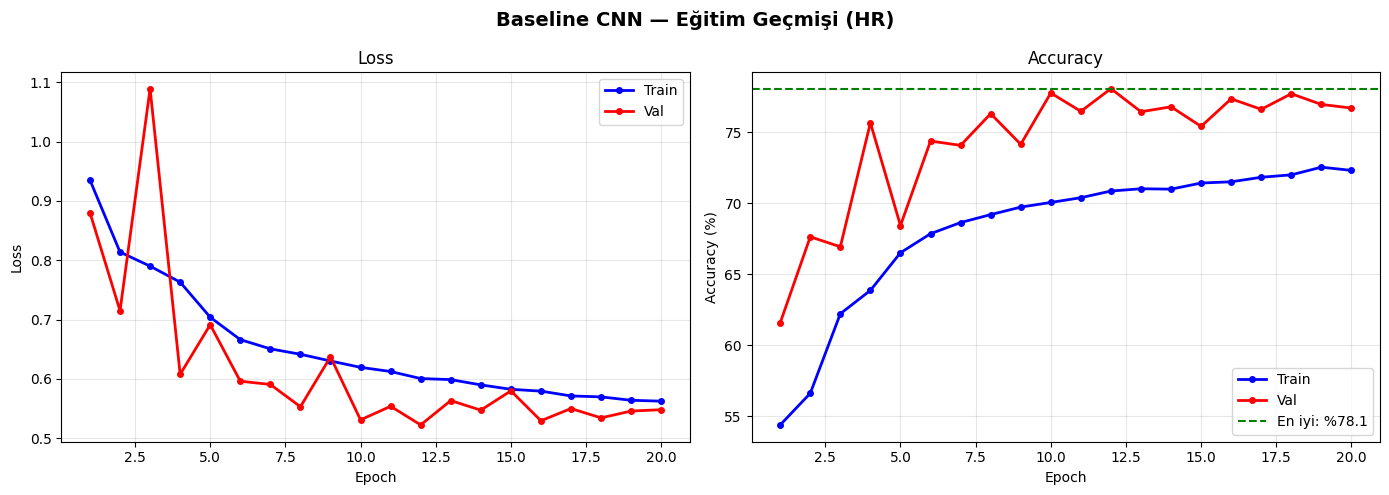

✅ En iyi Val Accuracy: %78.07


In [20]:
# ============================================================
# HÜCRE 5: EĞİTİM GRAFİKLERİ
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Eğitim Geçmişi (HR)",
             fontsize=14, fontweight='bold')

ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, tarih["train_loss"], 'b-o', ms=4, lw=2, label="Train")
axes[0].plot(ep, tarih["val_loss"],   'r-o', ms=4, lw=2, label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, tarih["train_acc"], 'b-o', ms=4, lw=2, label="Train")
axes[1].plot(ep, tarih["val_acc"],   'r-o', ms=4, lw=2, label="Val")
axes[1].axhline(y=en_iyi_val_acc, color='g', ls='--', lw=1.5,
                label=f"En iyi: %{en_iyi_val_acc:.1f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_egitim.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ En iyi Val Accuracy: %{en_iyi_val_acc:.2f}")

BASELINE CNN — TEST SONUÇLARI (HR)
              precision    recall  f1-score   support

     tubules     0.2843    0.7377    0.4104      1281
    branches     0.8785    0.5090    0.6446      3493
        both     0.8566    0.8162    0.8359     12172

    accuracy                         0.7470     16946
   macro avg     0.6731    0.6876    0.6303     16946
weighted avg     0.8179    0.7470    0.7643     16946


Per-class Sensitivity & Specificity:
Sınıf         Sensitivity  Specificity
--------------------------------------
tubules            0.7377       0.8481
branches           0.5090       0.9817
both               0.8162       0.6517

ROC-AUC (macro): 0.8797


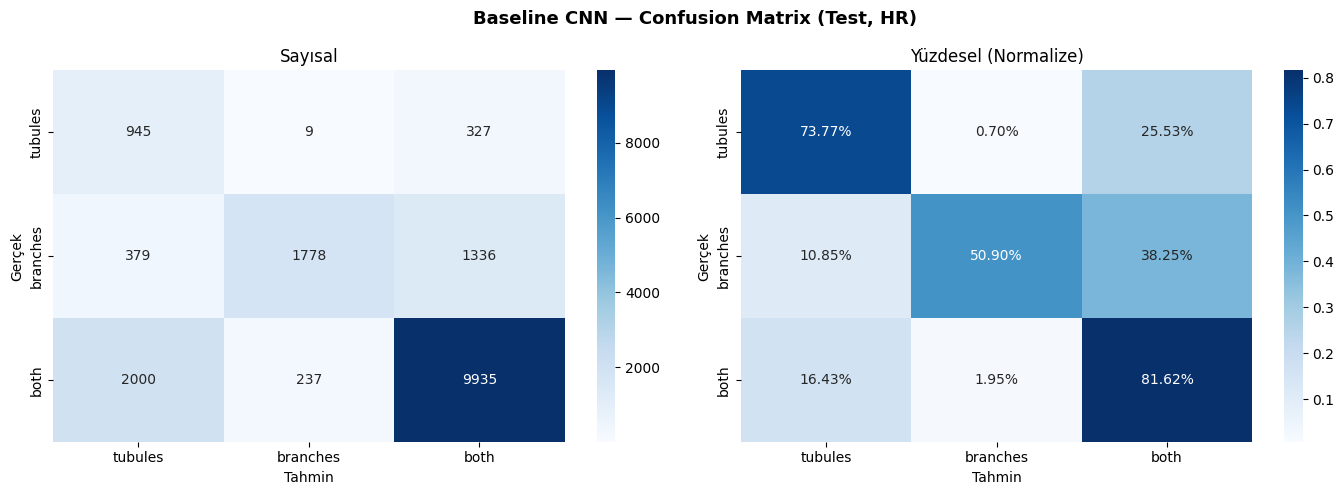

✅ Test değerlendirmesi tamamlandı!


In [21]:
# ============================================================
# HÜCRE 6: TEST SETİ DEĞERLENDİRME
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score)
import seaborn as sns

model.load_state_dict(torch.load("baseline_best.pth"))
model.eval()

tum_tahmin = []
tum_gercek = []
tum_prob   = []

with torch.no_grad():
    for imgs, eti in test_loader:
        imgs = imgs.to(DEVICE)
        cikti = model(imgs)
        prob  = torch.softmax(cikti, dim=1).cpu().numpy()
        tum_prob.extend(prob)
        tum_tahmin.extend(cikti.argmax(1).cpu().numpy())
        tum_gercek.extend(eti.numpy())

tum_tahmin = np.array(tum_tahmin)
tum_gercek = np.array(tum_gercek)
tum_prob   = np.array(tum_prob)

print("="*60)
print("BASELINE CNN — TEST SONUÇLARI (HR)")
print("="*60)
print(classification_report(tum_gercek, tum_tahmin,
                            target_names=SINIFLAR, digits=4))

print("\nPer-class Sensitivity & Specificity:")
print(f"{'Sınıf':<12} {'Sensitivity':>12} {'Specificity':>12}")
print("-"*38)
for i, sinif in enumerate(SINIFLAR):
    tp = ((tum_tahmin == i) & (tum_gercek == i)).sum()
    fn = ((tum_tahmin != i) & (tum_gercek == i)).sum()
    tn = ((tum_tahmin != i) & (tum_gercek != i)).sum()
    fp = ((tum_tahmin == i) & (tum_gercek != i)).sum()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{sinif:<12} {sens:>12.4f} {spec:>12.4f}")

try:
    auc = roc_auc_score(tum_gercek, tum_prob, multi_class='ovr', average='macro')
    print(f"\nROC-AUC (macro): {auc:.4f}")
except:
    print("\nROC-AUC hesaplanamadı")

cm = confusion_matrix(tum_gercek, tum_tahmin)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Confusion Matrix (Test, HR)",
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=SINIFLAR, yticklabels=SINIFLAR)
axes[0].set_xlabel("Tahmin"); axes[0].set_ylabel("Gerçek")
axes[0].set_title("Sayısal")

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=SINIFLAR, yticklabels=SINIFLAR)
axes[1].set_xlabel("Tahmin"); axes[1].set_ylabel("Gerçek")
axes[1].set_title("Yüzdesel (Normalize)")

plt.tight_layout()
plt.savefig("baseline_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Test değerlendirmesi tamamlandı!")